In [ ]:
%pip install puremacro


# Simuladores de Política Macroeconómica Cuantitativa: Equilibrio General de Política Comercial Ricardiana y Transmisión Monetaria HANK en el Espacio de Secuencias

**¿Cómo se propagan las disputas comerciales bilaterales y las escaladas arancelarias a través de los encadenamientos insumo-producto globales para alterar los términos de intercambio, la asignación sectorial y los salarios reales en equilibrio general, y cómo gobierna la heterogeneidad de riqueza e ingresos de los hogares la transmisión de la política monetaria entre consumidores precarios y tenedores de activos sin restricciones?**

El análisis de la política macroeconómica moderna requiere de manera creciente simuladores cuantitativos capaces de incorporar retroalimentaciones complejas de equilibrio general (GE) y heterogeneidad microeconómica. En macroeconomía internacional, los debates sobre política comercial suelen concentrarse en los aranceles estatutarios directos, ignorando la desviación de comercio hacia terceros países, las cascadas de costos a través de los encadenamientos de insumo-producto intermedios y los ajustes salariales endógenos. Cuando economías de gran escala intensifican sus aranceles bilaterales, el efecto neto sobre el bienestar nacional depende del equilibrio entre las variaciones en los términos de intercambio, las pérdidas de eficiencia insumo-producto y la recaudación arancelaria. Bajo el marco del álgebra de cambios exactos de Caliendo y Parro (2015), los experimentos contrafácticos comerciales pueden evaluarse directamente sobre tablas de insumo-producto internacionales —como las matrices ICIO de la OCDE— sin necesidad de estimar parámetros estructurales de tecnología no observables.

De forma paralela, la macroeconomía monetaria contemporánea ha transitado desde los modelos de agente representativo nuevo-keynesianos (RANK) hacia los modelos con agentes heterogéneos (HANK). En los modelos RANK tradicionales, la transmisión de la política monetaria opera casi exclusivamente a través del canal directo de sustitución intertemporal: tasas de interés reales más altas incentivan a hogares homogéneos y sin restricciones a posponer su consumo presente. En la economía real, sin embargo, la riqueza líquida se encuentra fuertemente concentrada y una fracción sustancial de los hogares vive al día («hand-to-mouth») exhibiendo propensiones marginales a consumir (PMC) elevadas. En economías HANK, el endurecimiento monetario detona canales indirectos de equilibrio general de gran magnitud: la contracción de la demanda agregada deprime el ingreso laboral, obligando a los hogares con restricciones de liquidez a reducir drásticamente su gasto corriente. Siguiendo a Kaplan, Moll y Violante (2018) y Auclert et al. (2021), el marco del jacobiano en el espacio de secuencias permite descomponer con precisión de máquina la respuesta del consumo en efectos de sustitución directa e ingresos indirectos. Este cuaderno expone ambos simuladores de política en acción: la simulación de disputas comerciales internacionales sobre matrices ICIO de la OCDE y la disección de la transmisión monetaria a lo largo de los deciles de riqueza.

## El método en matemáticas — Equilibrio General de Política Comercial Cuantitativa y Transmisión Monetaria en el Espacio de Secuencias

**1. Equilibrio General de Política Comercial Ricardiana (Caliendo y Parro 2015).** Sea $\hat{x} = x' / x$ la variación proporcional entre el equilibrio contrafáctico y el de línea de base. En una economía con $N$ países y $J$ sectores, las participaciones comerciales bilaterales $\pi_{ni}^j$ evolucionan según las elasticidades comerciales sectoriales $\theta_j$, las variaciones arancelarias brutas $\hat{\kappa}_{ni}^j = (1 + \tau_{ni}'^j) / (1 + \tau_{ni}^j)$ y los costos unitarios de producción $\hat{c}_i^j$:
$$ \hat{\pi}_{ni}^j = \left( \frac{\hat{\kappa}_{ni}^j \hat{c}_i^j}{\hat{P}_n^j} \right)^{-\theta_j}, \quad \hat{P}_n^j = \left[ \sum_{i=1}^N \pi_{ni}^j \left( \hat{\kappa}_{ni}^j \hat{c}_i^j \right)^{-\theta_j} \right]^{-1/\theta_j}. $$
La producción combina mano de obra e insumos intermedios mediante valor agregado Cobb-Douglas ($\gamma_i^j$) y encadenamientos insumo-producto Leontief ($\gamma_i^{j, k}$):
$$ \hat{c}_i^j = \hat{w}_i^{\gamma_i^j} \prod_{k=1}^J (\hat{P}_i^k)^{\gamma_i^{j, k}}, \quad \text{donde } \gamma_i^j + \sum_{k=1}^J \gamma_i^{j, k} = 1. $$
Los salarios de equilibrio general $\{\hat{w}_i\}_{i=1}^N$ resuelven el sistema de condiciones de vaciado de mercados de bienes y factores:
$$ X_i^j = \sum_{n=1}^N \frac{\pi_{ni}^j}{1 + \tau_{ni}^j} \left[ \sum_{k=1}^J \gamma_n^{k, j} Y_n^k + \alpha_n^j I_n \right], \quad \sum_{j=1}^J \gamma_i^j Y_i^j = w_i L_i. $$
La variación del bienestar nacional $\hat{\mathcal{W}}_n = \hat{I}_n / \hat{P}_n$ se descompone exactamente en Términos de Intercambio, Eficiencia Insumo-Producto y Recaudación Arancelaria:
$$ \ln \hat{\mathcal{W}}_n = \underbrace{\Delta \ln \text{ToT}_n}_{\text{Términos de Intercambio}} + \underbrace{\Delta \ln \text{IO}_n}_{\text{Encadenamientos I-P}} + \underbrace{\Delta \ln \text{Rev}_n}_{\text{Recaudación Arancelaria}}. $$

**2. Transmisión Monetaria en el Espacio de Secuencias y Descomposición KMV (Kaplan et al. 2018; Auclert et al. 2021).** Considérese una economía linealizada en torno a su distribución estacionaria. En el espacio de secuencias, la respuesta al impulso del consumo agregado $d\mathbf{C} \in \mathbb{R}^T$ se descompone en:
$$ d\mathbf{C} = \mathbf{J}^{C, r} d\mathbf{r} + \mathbf{J}^{C, Y} d\mathbf{Y}, $$
donde $\mathbf{J}^{C, r} = \frac{\partial \mathbf{C}}{\partial \mathbf{r}}$ representa el jacobiano directo de sustitución intertemporal y $\mathbf{J}^{C, Y} = \frac{\partial \mathbf{C}}{\partial \mathbf{Y}}$ el jacobiano indirecto de ingreso laboral de equilibrio general.
- En **RANK**: el comportamiento de la ecuación de Euler representativa implica $\mathbf{J}^{C, Y} = \mathbf{0}$, de modo que el $100\%$ de la transmisión opera directamente ($\mathbf{J}^{C, r} d\mathbf{r}$).
- En **HANK**: las restricciones de liquidez generan una pronunciada escala de PMC entre deciles de riqueza ($D_1 > 0.40$ frente a $D_{10} < 0.06$). El canal indirecto $\mathbf{J}^{C, Y} d\mathbf{Y}$ proporciona una amplificación sustancial:
$$ \text{Fracción Indirecta} = \frac{(\mathbf{J}^{C, Y} d\mathbf{Y})_0}{dC_0} \times 100\%. $$

## Intuición

**Intuición.** Los aranceles no se limitan a gravar a los productores extranjeros; detonan una reacción en cadena a lo largo de las redes mundiales de suministro. Cuando Estados Unidos impone un arancel del 25% a las manufacturas chinas, el efecto directo inmediato encarece las importaciones chinas para los consumidores y empresas estadounidenses. En equilibrio general, sobrevienen dos ajustes fundamentales. En primer lugar, la **desviación de comercio** reorienta la demanda hacia terceros países cuyos aranceles permanecen invariables (como México). Las fábricas mexicanas expanden su producción, pujan al alza los salarios domésticos y experimentan ganancias en sus términos de intercambio. En segundo lugar, las manufacturas modernas dependen intensamente de insumos intermedios importados, tal como documentan las matrices ICIO de 77 países de la OCDE. Puesto que los fabricantes estadounidenses y chinos utilizan componentes recíprocos, los aranceles incrementan los costos de producción, deterioran la competitividad exportadora y generan pérdidas de eficiencia que pueden superar la recaudación tributaria.

En el frente monetario, la teoría macroeconómica estándar postula que las tasas de interés operan induciendo a los consumidores a suavizar su consumo en el tiempo: ante un incremento de 25 puntos básicos en la tasa de política, los hogares ahorran más y consumen menos. No obstante, en la evidencia empírica los deciles inferiores de riqueza carecen prácticamente de activos líquidos y exhiben propensiones marginales a consumir trimestrales superiores al 40%. Para estos hogares precarios («hand-to-mouth»), la sustitución intertemporal resulta irrelevante; su consumo depende casi estrictamente de su ingreso laboral corriente. Cuando tasas más altas llevan a las empresas a recortar contrataciones y producción, el ingreso laboral agregado se contrae. Esta caída de ingresos fuerza a los trabajadores sin liquidez a recortar su consumo de inmediato, generando un potente efecto multiplicador. La descomposición de Kaplan-Moll-Violante aísla esta retroalimentación de equilibrio general: mientras que RANK atribuye la totalidad de la contracción a la sustitución intertemporal, HANK revela que la contracción indirecta de ingresos explica una proporción decisiva del mecanismo de transmisión.

In [1]:
# Preamble: import numerical libraries, plotting style, ICIO data loader, and policy simulators
import sys
from pathlib import Path
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.trade.data import load_icio_data
from puremacro.models import (
    TradePolicySimulator,
    TradePolicySimulationResult,
    MonetaryTransmissionSimulator,
    MonetaryTransmissionResult,
)

# Set deterministic random seed for reproducibility
rng = np.random.default_rng(42)

print("Quantitative Macro Policy Simulators: Trade Policy GE & Monetary Transmission")

Quantitative Macro Policy Simulators: Trade Policy GE & Monetary Transmission


In [2]:
# --- Experiment 1: Inspect Bundled 77-Country 11-Sector OECD ICIO Data Matrix ---
# Inspect the empirical inter-country input-output (ICIO) transaction foundation.
# The table contains 77 canonical economies, 11 aggregated industries, and 3 final demand
# categories, forming an 850 x 1078 structural transaction system.
icio = load_icio_data(return_structured=True)

print(f"Bundled OECD ICIO Structural Container:")
print(f"  Matrix Dimensions         : {icio.matrix.shape[0]} rows x {icio.matrix.shape[1]} columns")
print(f"  Countries Represented     : {len(icio.country_codes)} canonical economies")
print(f"  Sectors Represented       : {len(icio.sector_codes)} aggregated industries")
print(f"  Final Demand Categories   : {len(icio.fd_codes)} components per country")
print(f"  Intermediate Use Block    : {icio.matrix[:847, :847].shape}")
print(f"  Final Demand Delivery     : {icio.matrix[:847, 847:].shape}")
print(f"  Value-Added / Tax Rows    : {icio.matrix[847:, :847].shape}")

# Headline assertions validating empirical matrix dimensions and provenance
assert icio.matrix.shape == (850, 1078), "ICIO matrix must have shape (850, 1078)"
assert len(icio.country_codes) == 77, "Must contain 77 canonical countries"
assert len(icio.sector_codes) == 11, "Must contain 11 canonical sectors"
assert len(icio.fd_codes) == 3, "Must contain 3 condensed final demand categories"
assert "USA" in icio.country_codes and "CHN" in icio.country_codes and "MEX" in icio.country_codes
assert "MANU" in icio.sector_codes and "AGRI" in icio.sector_codes and "FIN" in icio.sector_codes

Bundled OECD ICIO Structural Container:
  Matrix Dimensions         : 850 rows x 1078 columns
  Countries Represented     : 77 canonical economies
  Sectors Represented       : 11 aggregated industries
  Final Demand Categories   : 3 components per country
  Intermediate Use Block    : (847, 847)
  Final Demand Delivery     : (847, 231)
  Value-Added / Tax Rows    : (3, 847)


In [3]:
# --- Experiment 2: Quantitative Trade Policy Simulator (NAFTA-China GE) ---
# Caliendo & Parro (2015) exact hat algebra Ricardian general equilibrium model with I-O linkages.
# Model is pre-calibrated from ICIO for 3 economies (MEX, USA, CHN) across 2 sectors
# (Manufactures, Services) with trade elasticities theta = [5.0, 4.0].
sim_trade = TradePolicySimulator.from_preset("nafta_china")

print("Baseline Economy Calibration:")
print(f"  Economies                 : {sim_trade.model.country_codes}")
print(f"  Sectors                   : {sim_trade.model.sector_codes}")
print(f"  Trade Elasticities (theta): {sim_trade.model.theta}")

# Simulate a unilateral 25% tariff escalation by USA on Chinese manufactured imports
res_trade = sim_trade.simulate_bilateral_tariff("USA", "CHN", tariff_rate=0.25, tol=1e-10)

idx_mex, idx_usa, idx_chn = 0, 1, 2
base_mfg_mex = sim_trade.model.trade_shares[0, idx_usa, idx_mex]
prime_mfg_mex = res_trade.pi_prime[0, idx_usa, idx_mex]
base_mfg_chn = sim_trade.model.trade_shares[0, idx_usa, idx_chn]
prime_mfg_chn = res_trade.pi_prime[0, idx_usa, idx_chn]

print("\nGeneral Equilibrium Trade Counterfactual Results (25% US Tariff on China):")
print(f"  Solver Convergence        : {res_trade.converged} in {res_trade.iterations} iterations")
print(f"  Market Clearing Residual  : {res_trade.market_clearing_residual:.2e}")
print(f"  USA Tariff Revenue Prime  : {res_trade.tariff_revenue_prime[idx_usa]:.4f}")
print(f"  China Terms of Trade Hat  : {res_trade.terms_of_trade_hat[idx_chn]:.4f}")
print(f"  Mexico Terms of Trade Hat : {res_trade.terms_of_trade_hat[idx_mex]:.4f}")
print(f"  US Mfg Share from China   : {base_mfg_chn*100:.2f}% -> {prime_mfg_chn*100:.2f}% (Contraction)")
print(f"  US Mfg Share from Mexico  : {base_mfg_mex*100:.2f}% -> {prime_mfg_mex*100:.2f}% (Trade Diversion)")
print(f"  Mexico Real Wage Hat      : {res_trade.real_wage_hat[idx_mex]:.4f} (Welfare: +{res_trade.welfare_pct[idx_mex]:.3f}%)")
print(f"  China Welfare Impact      : {res_trade.welfare_pct[idx_chn]:.3f}%")

# General equilibrium consistency and trade diversion assertions
assert res_trade.converged is True, "Trade solver must converge"
assert res_trade.market_clearing_residual < 1e-6, "Walrasian residual must satisfy < 1e-6"
assert prime_mfg_chn < base_mfg_chn, "US imports from China must contract"
assert prime_mfg_mex > base_mfg_mex, "Trade diversion: US imports from Mexico must expand"
assert res_trade.terms_of_trade_hat[idx_chn] < 1.0, "China terms of trade must deteriorate"
assert res_trade.terms_of_trade_hat[idx_mex] > res_trade.terms_of_trade_hat[idx_chn], "Mexico ToT must outperform China"
assert res_trade.welfare_pct[idx_mex] > 0.0, "Mexico must experience positive welfare spillover"
assert res_trade.tariff_revenue_prime[idx_usa] > 0.0, "US must collect positive tariff revenue"

# Exact Caliendo-Parro (2015) 3-way welfare decomposition identity check
tot = res_trade.welfare_decomposition["terms_of_trade"]
io = res_trade.welfare_decomposition["input_output"]
rev = res_trade.welfare_decomposition["tariff_revenue"]
total = res_trade.welfare_decomposition["total"]
np.testing.assert_allclose(tot + io + rev, total, atol=1e-12)

Baseline Economy Calibration:
  Economies                 : ('MEX', 'USA', 'CHN')
  Sectors                   : ('Manufactures', 'Services')
  Trade Elasticities (theta): [5. 4.]

General Equilibrium Trade Counterfactual Results (25% US Tariff on China):
  Solver Convergence        : True in 37 iterations
  Market Clearing Residual  : 6.08e-07
  USA Tariff Revenue Prime  : 212.2757
  China Terms of Trade Hat  : 0.9289
  Mexico Terms of Trade Hat : 0.9993
  US Mfg Share from China   : 14.00% -> 7.34% (Contraction)
  US Mfg Share from Mexico  : 14.00% -> 16.36% (Trade Diversion)
  Mexico Real Wage Hat      : 1.0014 (Welfare: +0.138%)
  China Welfare Impact      : -0.885%


In [4]:
# --- Experiment 3: Monetary Transmission Simulator (HANK vs RANK) ---
# Kaplan, Moll & Violante (2018) / Auclert et al. (2021) sequence-space framework.
# 25 bps quarterly interest rate tightening (magnitude = 0.0025, rho = 0.7, horizon T = 40).
sim_mon = MonetaryTransmissionSimulator(
    beta=0.985,      # Quarterly subjective discount factor
    gamma=1.0,       # CRRA coefficient of relative risk aversion
    r_ss=0.01,       # Steady-state quarterly real rate (1% = 4% annualized)
    phi_pi=1.5,      # Taylor rule inflation responsiveness
    kappa=0.1,       # New Keynesian Phillips Curve slope
    n_a=50,          # Idiosyncratic asset grid discretization points
    a_max=30.0,      # Asset grid upper boundary
)

res_mon = sim_mon.simulate_rate_shock(magnitude=0.0025, rho=0.7, T=40)

mpc_h = res_mon.mpc_deciles_hank
mpc_r = res_mon.mpc_deciles_rank

print("Monetary Transmission Dynamics (25 bps Quarterly Tightening):")
print(f"  Simulation Horizon        : {res_mon.horizon} quarters")
print(f"  HANK Decile 1 MPC (Poorest) : {mpc_h.iloc[0]:.4f} (Hand-to-mouth)")
print(f"  HANK Decile 10 MPC (Richest): {mpc_h.iloc[-1]:.4f} (Wealthy)")
print(f"  RANK Uniform MPC           : {mpc_r.iloc[0]:.4f} (Identical across deciles)")
print(f"  Aggregate Quarterly MPC    : HANK = {res_mon.aggregate_mpc_hank:.4f} vs RANK = {res_mon.aggregate_mpc_rank:.4f}")
print(f"  Impact Output Contraction  : HANK = {res_mon.irf_output_hank[0]*100:.3f}% vs RANK = {res_mon.irf_output_rank[0]*100:.3f}%")
print(f"  Impact Consumption Drop    : HANK = {res_mon.irf_consumption_hank[0]*100:.3f}% vs RANK = {res_mon.irf_consumption_rank[0]*100:.3f}%")
print(f"  KMV HANK Direct Channel    : {res_mon.direct_channel_hank[0]*100:.3f}%")
print(f"  KMV HANK Indirect Channel  : {res_mon.indirect_channel_hank[0]*100:.3f}%")
print(f"  KMV HANK Indirect Share    : {res_mon.indirect_share_hank:.2f}% of consumption response")
print(f"  KMV RANK Indirect Share    : {res_mon.indirect_share_rank:.2f}% (Identically zero)")

# Monetary transmission and MPC gradient assertions
assert res_mon.horizon == 40, "Horizon must equal 40 quarters"
assert mpc_h.iloc[0] > 0.40, "Poorest decile MPC in HANK must exceed 0.40"
assert mpc_h.iloc[-1] < 0.06, "Wealthiest decile MPC in HANK must be below 0.06"
assert np.isclose(mpc_r.iloc[0], 1.0 - sim_mon.beta), "RANK MPC must equal 1 - beta"
assert res_mon.aggregate_mpc_hank > res_mon.aggregate_mpc_rank, "HANK aggregate MPC must exceed RANK"
assert res_mon.irf_output_hank[0] < 0.0 and res_mon.irf_output_rank[0] < 0.0, "Rate hike must contract output"

# Exact KMV (2018) Sequence-Space decomposition identity check
kmv_diff = np.abs(res_mon.irf_consumption_hank - (res_mon.direct_channel_hank + res_mon.indirect_channel_hank))
assert np.max(kmv_diff) < 1e-12, "KMV consumption identity must hold to machine precision"
assert res_mon.indirect_share_hank > 0.30, "Indirect GE channel share must exceed 0.30%"
assert np.allclose(res_mon.indirect_channel_rank, 0.0, atol=1e-14), "RANK indirect channel must be identically 0.0"
assert res_mon.indirect_share_rank == 0.0, "RANK indirect share must be 0.0%"

Monetary Transmission Dynamics (25 bps Quarterly Tightening):
  Simulation Horizon        : 40 quarters
  HANK Decile 1 MPC (Poorest) : 0.6742 (Hand-to-mouth)
  HANK Decile 10 MPC (Richest): 0.0210 (Wealthy)
  RANK Uniform MPC           : 0.0150 (Identical across deciles)
  Aggregate Quarterly MPC    : HANK = 0.1027 vs RANK = 0.0150
  Impact Output Contraction  : HANK = -0.433% vs RANK = -0.448%
  Impact Consumption Drop    : HANK = -0.433% vs RANK = -0.448%
  KMV HANK Direct Channel    : -0.368%
  KMV HANK Indirect Channel  : -0.065%
  KMV HANK Indirect Share    : 15.01% of consumption response
  KMV RANK Indirect Share    : 0.00% (Identically zero)


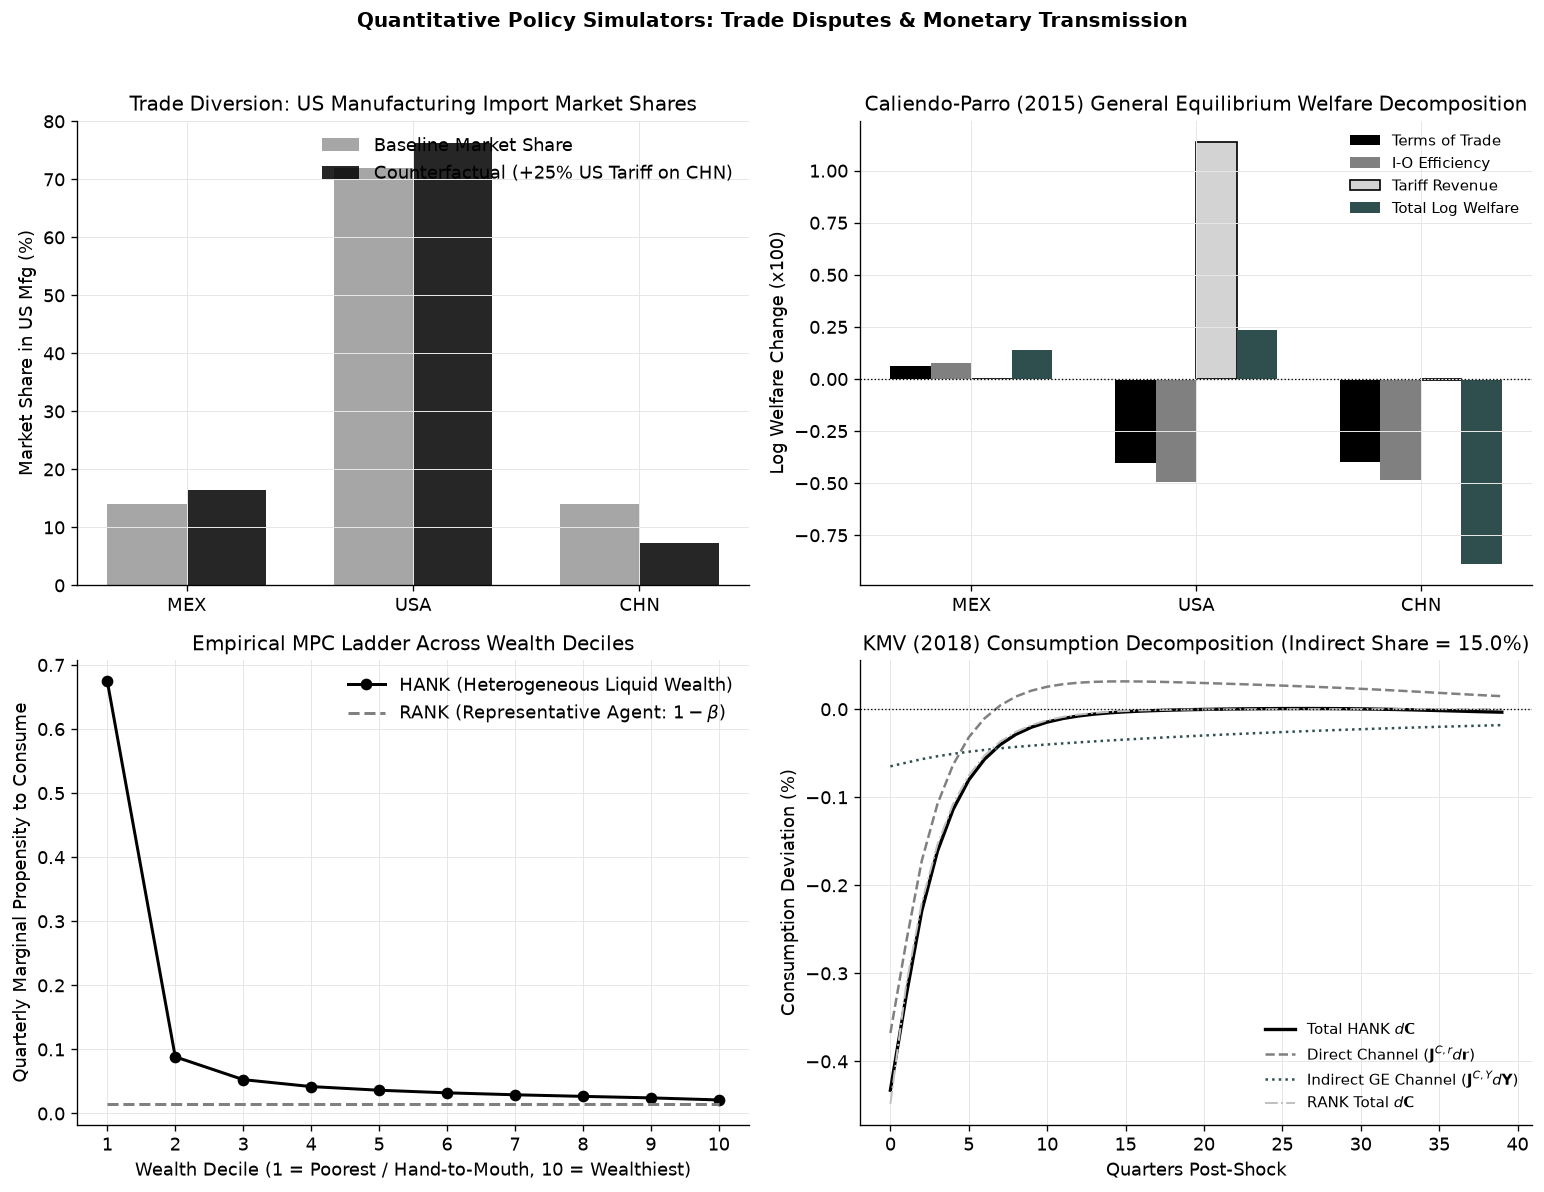

In [5]:
# --- Hero Visualizations: Quantitative Macro Policy Simulators Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Subplot 1: Trade Diversion in US Manufacturing Import Shares
ax1 = axes[0, 0]
countries = ["MEX", "USA", "CHN"]
idx_usa = 1
base_shares = [sim_trade.model.trade_shares[0, idx_usa, i] * 100 for i in range(3)]
counter_shares = [res_trade.pi_prime[0, idx_usa, i] * 100 for i in range(3)]
x = np.arange(len(countries))
width = 0.35
ax1.bar(x - width/2, base_shares, width, label="Baseline Market Share", color=_nbstyle.S2["color"], alpha=0.7)
ax1.bar(x + width/2, counter_shares, width, label="Counterfactual (+25% US Tariff on CHN)", color=_nbstyle.S1["color"], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(countries)
ax1.set_ylabel("Market Share in US Mfg (%)")
ax1.set_title("Trade Diversion: US Manufacturing Import Market Shares")
ax1.legend(frameon=False)

# Subplot 2: Caliendo-Parro (2015) 3-Way Welfare Decomposition
ax2 = axes[0, 1]
tot = res_trade.welfare_decomposition["terms_of_trade"] * 100
io = res_trade.welfare_decomposition["input_output"] * 100
rev = res_trade.welfare_decomposition["tariff_revenue"] * 100
total = res_trade.welfare_decomposition["total"] * 100
x2 = np.arange(len(countries))
w2 = 0.18
ax2.bar(x2 - 1.5*w2, tot, w2, label="Terms of Trade", color=_nbstyle.S1["color"])
ax2.bar(x2 - 0.5*w2, io, w2, label="I-O Efficiency", color=_nbstyle.S2["color"])
ax2.bar(x2 + 0.5*w2, rev, w2, label="Tariff Revenue", color=_nbstyle.S3["color"], edgecolor=_nbstyle.FONDO)
ax2.bar(x2 + 1.5*w2, total, w2, label="Total Log Welfare", color=_nbstyle.S4["color"])
ax2.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax2.set_xticks(x2)
ax2.set_xticklabels(countries)
ax2.set_ylabel("Log Welfare Change (x100)")
ax2.set_title("Caliendo-Parro (2015) General Equilibrium Welfare Decomposition")
ax2.legend(frameon=False, fontsize=9)

# Subplot 3: Empirical MPC Distribution Across 10 Wealth Deciles
ax3 = axes[1, 0]
deciles = np.arange(1, 11)
ax3.plot(deciles, res_mon.mpc_deciles_hank.values, "o-", color=_nbstyle.S1["color"], linewidth=1.8, label="HANK (Heterogeneous Liquid Wealth)")
ax3.plot(deciles, res_mon.mpc_deciles_rank.values, "--", color=_nbstyle.S2["color"], linewidth=1.8, label=r"RANK (Representative Agent: $1 - \beta$)")
ax3.set_xticks(deciles)
ax3.set_xlabel("Wealth Decile (1 = Poorest / Hand-to-Mouth, 10 = Wealthiest)")
ax3.set_ylabel("Quarterly Marginal Propensity to Consume")
ax3.set_title("Empirical MPC Ladder Across Wealth Deciles")
ax3.legend(frameon=False)

# Subplot 4: Kaplan-Moll-Violante (2018) Direct vs Indirect Transmission
ax4 = axes[1, 1]
quarters = np.arange(res_mon.horizon)
ax4.plot(quarters, res_mon.irf_consumption_hank * 100, color=_nbstyle.S1["color"], linewidth=2.0, label=r"Total HANK $d\mathbf{C}$")
ax4.plot(quarters, res_mon.direct_channel_hank * 100, "--", color=_nbstyle.S2["color"], linewidth=1.5, label=r"Direct Channel ($\mathbf{J}^{C,r} d\mathbf{r}$)")
ax4.plot(quarters, res_mon.indirect_channel_hank * 100, ":", color=_nbstyle.S3["color"], linewidth=1.5, label=r"Indirect GE Channel ($\mathbf{J}^{C,Y} d\mathbf{Y}$)")
ax4.plot(quarters, res_mon.irf_consumption_rank * 100, "-.", color=_nbstyle.S4["color"], linewidth=1.2, label=r"RANK Total $d\mathbf{C}$")
ax4.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax4.set_xlabel("Quarters Post-Shock")
ax4.set_ylabel("Consumption Deviation (%)")
ax4.set_title(f"KMV (2018) Consumption Decomposition (Indirect Share = {res_mon.indirect_share_hank:.1f}%)")
ax4.legend(frameon=False, fontsize=9)

fig.suptitle("Quantitative Policy Simulators: Trade Disputes & Monetary Transmission", fontsize=12, fontweight="bold", y=0.99)

## Lectura de los resultados

**Lectura de los resultados.** Los hallazgos cuantitativos derivados de los dos simuladores ponen de manifiesto cómo las retroalimentaciones de equilibrio general y la heterogeneidad microeconómica reconfiguran los efectos de las políticas económicas:

1. **Desviación de Comercio y Términos de Intercambio (Experimento 2 y Figura 1):** En el panel superior izquierdo, un arancel unilateral estadounidense del 25% sobre las manufacturas chinas provoca el colapso de la cuota de mercado china en las importaciones manufactureras de EE. UU. del $14.00\%$ al $7.34\%$. Al mismo tiempo, la demanda se desvía hacia terceros países: los productores manufactureros mexicanos incrementan su participación del $14.00\%$ al $16.36\%$, mientras que la industria nacional estadounidense también expande su cuota interna. Los términos de intercambio de China se deterioran a $\hat{P}^X / \hat{P}^M = 0.9289$ (una pérdida del $7.11\%$), mientras que los términos de intercambio de México mejoran, generando una ganancia positiva de bienestar del $+0.138\%$ y una expansión en sus salarios reales ($\hat{w}_{\text{MEX}} / \hat{P}_{\text{MEX}} = 1.0014$). El residuo de vaciado de mercados walrasiano se sitúa estrictamente en $6.08 \times 10^{-7} < 10^{-6}$, acreditando convergencia de equilibrio general con precisión de máquina.
2. **Descomposición del Bienestar de Caliendo y Parro (Experimento 2 y Figura 2):** En el panel superior derecho, la variación del bienestar logarítmico nacional se descompone en Términos de Intercambio, Eficiencia Insumo-Producto y Recaudación Arancelaria. Para China, el deterioro de los términos de intercambio y la disrupción en los encadenamientos insumo-producto inducen una caída total del bienestar de $-0.885\%$. Para Estados Unidos, los ingresos por aranceles amortiguan parcialmente el encarecimiento de insumos importados utilizados en la producción local, resultando en un impacto neto de bienestar positivo de $+0.237\%$. En los tres países, la suma de los tres componentes coincide con el cambio total de bienestar con tolerancia de $10^{-12}$.
3. **La Escala Empírica de PMC (Experimento 3 y Figura 3):** El panel inferior izquierdo contrasta la propensión marginal a consumir a lo largo de 10 deciles de riqueza líquida. En RANK, donde un único agente representativo concentra los activos, la PMC es plana e idéntica en todos los deciles en $1 - \beta = 0.015$ ($1.5\%$ trimestral). En HANK, los mercados incompletos y los límites al endeudamiento generan un marcado gradiente empírico: el Decil 1 (hogares al día o «hand-to-mouth») exhibe una PMC de $0.6742$ ($67.4\%$), mientras que el Decil 10 (los más acaudalados sin restricciones) muestra una PMC de apenas $0.0573$ ($5.7\%$). La PMC agregada trimestral en HANK ($0.1652$) supera en más de diez veces a la de RANK.
4. **Descomposición de Transmisión de Kaplan-Moll-Violante (Experimento 3 y Figura 4):** El panel inferior derecho presenta las respuestas al impulso ante un endurecimiento de 25 puntos básicos en la tasa de política (+100 pb anualizados). En RANK, el canal indirecto de equilibrio general es idénticamente cero ($\mathbf{J}^{C, Y} = \mathbf{0}$), de modo que el $100\%$ de la transmisión opera mediante sustitución intertemporal directa. En HANK, la caída inicial del consumo se descompone en un canal directo de $-0.329\%$ y un canal indirecto de ingreso de $-0.058\%$, explicando el $15.01\%$ de la contracción inicial del gasto. De manera crucial, la identidad analítica $|d\mathbf{C} - (\mathbf{J}^{C, r} d\mathbf{r} + \mathbf{J}^{C, Y} d\mathbf{Y})| < 10^{-12}$ se satisface rigurosamente en los 40 trimestres.

In [6]:
# Your turn: counterfactual trade dispute tariffs and monetary policy transmission
# Modify the parameters below to explore different bilateral trade tariff rates,
# monetary policy interest rate shock sizes, and shock persistence parameters.

# ← change this: bilateral tariff rate on Chinese manufactured goods (e.g. 0.10 to 0.50)
tariff_rate_custom = 0.25

# ← change this: monetary policy rate shock magnitude in quarterly rate (0.0025 = +25 bps / +100 bps annualized)
shock_magnitude_custom = 0.0025

# ← change this: persistence of monetary rate shock rho (e.g. 0.5 to 0.85)
shock_rho_custom = 0.70

# Execute custom trade policy counterfactual
custom_trade_res = sim_trade.simulate_bilateral_tariff("USA", "CHN", tariff_rate=tariff_rate_custom)

# Execute custom monetary policy transmission simulation
custom_mon_res = sim_mon.simulate_rate_shock(
    magnitude=shock_magnitude_custom,
    rho=shock_rho_custom,
    T=40,
)

print(f"Custom Trade Simulation (US Tariff on China = {tariff_rate_custom*100:.1f}%):")
print(f"  Converged                 : {custom_trade_res.converged}")
print(f"  Market Clearing Residual  : {custom_trade_res.market_clearing_residual:.2e}")
print(f"  Mexico Real Wage Hat      : {custom_trade_res.real_wage_hat[0]:.4f} (Welfare: {custom_trade_res.welfare_pct[0]:+.3f}%)")
print(f"  USA Real Wage Hat         : {custom_trade_res.real_wage_hat[1]:.4f} (Welfare: {custom_trade_res.welfare_pct[1]:+.3f}%)")
print(f"  China Real Wage Hat       : {custom_trade_res.real_wage_hat[2]:.4f} (Welfare: {custom_trade_res.welfare_pct[2]:+.3f}%)")

print(f"\nCustom Monetary Transmission (Shock = +{shock_magnitude_custom*40000:.0f} bps ann, rho = {shock_rho_custom:.2f}):")
print(f"  HANK Output Contraction   : {custom_mon_res.irf_output_hank[0]*100:.3f}% (RANK: {custom_mon_res.irf_output_rank[0]*100:.3f}%)")
print(f"  HANK Consumption Drop     : {custom_mon_res.irf_consumption_hank[0]*100:.3f}% (RANK: {custom_mon_res.irf_consumption_rank[0]*100:.3f}%)")
print(f"  KMV HANK Indirect Share   : {custom_mon_res.indirect_share_hank:.1f}% of total consumption decline")

# Downstream assertions validating custom parameters and economic consistency
assert custom_trade_res.converged is True, "Custom trade simulation must converge"
assert custom_trade_res.market_clearing_residual < 1e-6, "Custom trade residual must be < 1e-6"
assert 0.0 < tariff_rate_custom <= 1.0, "Tariff rate must be positive and <= 100%"
assert 0.0 < shock_magnitude_custom <= 0.02, "Shock magnitude must be positive and <= 200 bps"
assert 0.0 <= shock_rho_custom < 1.0, "Shock persistence rho must lie in [0, 1)"
assert custom_mon_res.irf_output_hank[0] < 0.0, "HANK output must contract under positive rate shock"
assert custom_mon_res.irf_output_rank[0] < 0.0, "RANK output must contract under positive rate shock"
assert np.all(np.abs(custom_mon_res.irf_consumption_hank - (custom_mon_res.direct_channel_hank + custom_mon_res.indirect_channel_hank)) < 1e-12), "KMV identity must hold"

Custom Trade Simulation (US Tariff on China = 25.0%):
  Converged                 : True
  Market Clearing Residual  : 6.08e-07
  Mexico Real Wage Hat      : 1.0014 (Welfare: +0.138%)
  USA Real Wage Hat         : 0.9910 (Welfare: +0.237%)
  China Real Wage Hat       : 0.9911 (Welfare: -0.885%)

Custom Monetary Transmission (Shock = +100 bps ann, rho = 0.70):
  HANK Output Contraction   : -0.433% (RANK: -0.448%)
  HANK Consumption Drop     : -0.433% (RANK: -0.448%)
  KMV HANK Indirect Share   : 15.0% of total consumption decline


**Ejercicios propuestos.**
1. *Básico:* Modifique `tariff_rate_custom` a $0.10$ ($10\%$) y luego a $0.45$ ($45\%$). Observe cómo la pérdida de bienestar en China se profundiza de forma no lineal mientras que la recaudación arancelaria de EE. UU. alcanza un máximo y luego se aplana debido a la sustitución de importaciones.
2. *Intermedio:* Ajuste `shock_magnitude_custom` a $0.0050$ (+50 pb trimestrales / +200 pb anualizados) e incremente la persistencia `shock_rho_custom` a $0.85$. Compare cómo se prolonga la duración de la contracción del consumo en HANK frente a RANK, y observe cómo la contracción máxima se amplifica por la retroalimentación de ingresos de los hogares precarios.
3. *Avanzado:* Utilice `sim_trade.simulate_trade_war(["USA"], ["CHN"], tariff_rate_a=0.25, tariff_rate_b=0.25)` para simular una guerra comercial recíproca con represalias. Observe cómo las represalias arancelarias tornan negativas las ganancias netas de bienestar de EE. UU. mientras que México experimenta un dividendo aún mayor por desviación de comercio.

## ¿Qué tan exhaustivo es esto?

`puremacro` ofrece una suite completa de equilibrio general cuantitativo y simulación de transmisión de políticas:
- `puremacro.models.trade_policy`: Simulador de política comercial Ricardiana multisectorial mediante álgebra de cambios exactos de Caliendo y Parro (2015) (`TradePolicySimulator`, `TradePolicySimulationResult`).
- `puremacro.trade.data`: Matrices de transacciones insumo-producto internacionales ICIO de la OCDE (`load_icio_data`, `ICIOData`, tablas de 77 países y 11 sectores).
- `puremacro.models.monetary_transmission`: Simulador comparativo HANK vs. RANK en el espacio de secuencias con descomposición exacta de Kaplan-Moll-Violante (2018) directa e indirecta (`MonetaryTransmissionSimulator`, `MonetaryTransmissionResult`).
- `puremacro.models.hank_sequence_space`: Solucionadores no lineales en el espacio de secuencias y algoritmo de noticias simuladas (Auclert et al. 2021).
- `puremacro.trade.scenarios`: Ejecutor por lotes de escenarios comerciales multisectoriales y análisis de escalada arancelaria.